<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🛒 Consumer Behavior: Cluster Analysis 🛍️
    </h1>
</div>

# 📌 Overview

This project focuses on **Customer Personality Analysis** — a marketing analytics task designed to **understand customer behavior**, **identify target segments**, and **personalize marketing campaigns** for maximum efficiency.

The dataset contains rich information about customers’ **demographics, spending habits, lifestyle patterns, and campaign responses**, enabling a holistic view of who the customers are and how they interact with different products and promotions.

Dataset link: [Customer Personality Analysis (Kaggle)](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

**Goals:**

* Analyze key **demographic and behavioral factors** influencing purchasing decisions.
* Perform **segmentation (K-Means / Hierarchical Clustering)** to group customers into meaningful clusters.
* Identify **high-value customers** and understand which factors drive **campaign success**.
* Provide **business insights** for customer retention, product positioning, and targeted marketing.

🔑 **Key Features**

| Feature               | Description                                                   |
| --------------------- | ------------------------------------------------------------- |
| `ID`                  | Unique customer identifier                                    |
| `Year_Birth`          | Year of birth (used to derive age)                            |
| `Education`           | Education level (Graduation, PhD, Master, etc.)               |
| `Marital_Status`      | Marital status (Single, Married, Together, etc.)              |
| `Income`              | Annual household income (numeric, may contain missing values) |
| `Kidhome`             | Number of children in the household                           |
| `Teenhome`            | Number of teenagers in the household                          |
| `Dt_Customer`         | Date of customer enrollment with the company                  |
| `Recency`             | Number of days since the last purchase                        |
| `MntWines`            | Amount spent on wine in the last 2 years                      |
| `MntFruits`           | Amount spent on fruits                                        |
| `MntMeatProducts`     | Amount spent on meat products                                 |
| `MntFishProducts`     | Amount spent on fish products                                 |
| `MntSweetProducts`    | Amount spent on sweets                                        |
| `MntGoldProds`        | Amount spent on gold products                                 |
| `NumDealsPurchases`   | Number of purchases made with discounts                       |
| `NumWebPurchases`     | Number of purchases made through the website                  |
| `NumCatalogPurchases` | Number of purchases made using a catalog                      |
| `NumStorePurchases`   | Number of direct store purchases                              |
| `NumWebVisitsMonth`   | Number of website visits in the last month                    |
| `AcceptedCmp1–5`      | Campaign acceptance flags (1 = accepted, 0 = rejected)        |
| `Response`            | Response to the last campaign (target for classification)     |
| `Complain`            | Whether the customer complained in the last 2 years (1/0)     |
| `Country`             | Customer’s country of residence                               |

**Feature Highlights:**

* **Demographics:** `Year_Birth`, `Education`, `Marital_Status`, `Income`
* **Spending Behavior:** `MntWines`, `MntMeatProducts`, `MntGoldProds`, etc.
* **Engagement:** `NumWebPurchases`, `NumStorePurchases`, `Recency`
* **Campaign Interaction:** `AcceptedCmp1–5`, `Response`.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [210]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy.stats import skew

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [211]:
# Load the datasets
df = pd.read_csv("marketing_campaign.csv", sep="\t")
# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (2240, 29)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [212]:
# Display few rows of each dataset
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [213]:
# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The **dataset** contains **2,240** samples with **29** columns.
* The data covers **demographic**, **household**, **spending**, and **marketing campaign interaction** attributes.

**Feature Overview**

* The dataset includes all key customer-related information:

  * **Numerical features:**
    `Year_Birth`, `Income`, `Kidhome`, `Teenhome`, `Recency`,
    `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`,
    `MntSweetProducts`, `MntGoldProds`, `NumDealsPurchases`,
    `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`,
    `NumWebVisitsMonth`, `AcceptedCmp1`, `AcceptedCmp2`,
    `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `Complain`,
    `Z_CostContact`, `Z_Revenue`, `Response`.
  * **Categorical features:**
    `Education`, `Marital_Status`, `Dt_Customer`.
  * **Identifier:**
    `ID` (not useful for modeling).

**Data Completeness**

* Data types are appropriate: **numerical** features are `int64` or `float64`, and **categorical** features are `object`.
* The column `Income` contains **24 missing values (≈1.1%)** — imputation may be required.
* Columns `Z_CostContact` and `Z_Revenue` are **constant** and can be excluded from analysis.
* The column `ID` is an **identifier** and not meaningful for analytical or predictive tasks — it should be dropped.

In [214]:
df.drop(columns=["Z_Revenue", "Z_CostContact"], axis=1, inplace=True)

In [215]:
num_features = ["Year_Birth", "Income", "Recency","MntWines", "MntFruits", "MntMeatProducts", 
                "MntFishProducts","MntSweetProducts", "MntGoldProds", "NumDealsPurchases","NumWebPurchases", 
                "NumCatalogPurchases", "NumStorePurchases","NumWebVisitsMonth"]

cat_features = ["Education", "Marital_Status", "Response", "Complain", "Kidhome", "Teenhome", 
                "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.000000,1968.805804,11.984069,1893.000000,1959.000000,1970.000000,1977.000000,1996.000000
Income,2216.000000,52247.251354,25173.076661,1730.000000,35303.000000,51381.500000,68522.000000,666666.000000
Recency,2240.000000,49.109375,28.962453,0.000000,24.000000,49.000000,74.000000,99.000000
MntWines,2240.000000,303.935714,336.597393,0.000000,23.750000,173.500000,504.250000,1493.000000
MntFruits,2240.000000,26.302232,39.773434,0.000000,1.000000,8.000000,33.000000,199.000000
MntMeatProducts,2240.000000,166.950000,225.715373,0.000000,16.000000,67.000000,232.000000,1725.000000
MntFishProducts,2240.000000,37.525446,54.628979,0.000000,3.000000,12.000000,50.000000,259.000000
MntSweetProducts,2240.000000,27.062946,41.280498,0.000000,1.000000,8.000000,33.000000,263.000000
MntGoldProds,2240.000000,44.021875,52.167439,0.000000,9.000000,24.000000,56.000000,362.000000
NumDealsPurchases,2240.000000,2.325000,1.932238,0.000000,1.000000,2.000000,3.000000,15.000000


## Descriptive Insights from Dataset Statistics

* **Year_Birth:**
  Average around **1969**, with range **1959–1996** → most customers are **aged between 29–66 years**, centered around **middle-aged adults**.

* **Income:**
  Mean income ≈ **$52,247**, ranging from **$35K to $666K** → indicates **very high income disparity** and likely presence of **outliers** or extremely high-earning customers.

* **Recency:**
  Average **49 days**, spanning **0–99 days** → customer activity is **evenly distributed**, with some highly active and some inactive segments.

* **Spending on Wines (`MntWines`):**
  Average spending ≈ **$304**, with large variance → **wine purchases dominate** total spending, indicating strong preference for premium consumables.

* **Spending on Fruits, Meat, Fish, Sweets, Gold Products:**

  * **Meat products (`MntMeatProducts`)** have the highest mean (**$167**) after wines.
  * **Fish, sweets, and fruits** average around **$25–37**, suggesting **lower-frequency but diverse purchases**.
  * **Gold products** average **$44**, but max **$362** → occasional high-value luxury buys.

* **Purchase Behavior:**

  * **NumDealsPurchases:** mean ≈ **2.3**, showing **moderate sensitivity to discounts**.
  * **NumWebPurchases:** mean **4.1**, slightly below **NumStorePurchases (5.8)** → customers still **prefer in-store transactions**.
  * **NumCatalogPurchases:** mean **2.6** → catalog shopping plays a smaller role.
  * **NumWebVisitsMonth:** mean **5.5 visits/month**, indicating **consistent digital engagement** but not excessive browsing.

**Summary:**
The dataset represents a **financially diverse, middle-aged customer base** with **mixed purchasing behavior** across channels.
High spending in **wines** and **meat products**, along with large **income variation**, suggests potential segmentation by **lifestyle and purchasing power**.
Features like **Recency**, **Income**, and **product-specific expenditures** are likely strong drivers for **campaign response prediction** and **customer clustering**.

In [216]:
print("\nData describe:")
def convert_cat(features, df = df):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features)

display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))


Data describe:


,count,unique,top,freq
Education,2240,5,Graduation,1127
Marital_Status,2240,8,Married,864
Response,2240,2,0,1906
Complain,2240,2,0,2219
Kidhome,2240,3,0,1293
Teenhome,2240,3,0,1158
AcceptedCmp1,2240,2,0,2096
AcceptedCmp2,2240,2,0,2210
AcceptedCmp3,2240,2,0,2077
AcceptedCmp4,2240,2,0,2073


## Descriptive Insights for Categorical Features

* **Education:** 5 levels → *Graduation* (~50%) → most customers hold a college degree.
* **Marital_Status:** 8 categories → *Married* (~39%) → majority are married adults.
* **Response:** Binary (0/1) → only ~15% positive responses → low campaign conversion rate.
* **Complain:** 99% have no complaints → generally high customer satisfaction.
* **Kidhome / Teenhome:** mostly 0 → majority of households have **no children**.
* **AcceptedCmp1–5:** over 90% are 0 → previous campaigns had **low response rates**.

**Summary:**
Customers are mainly **educated, married adults** with **no young children**.
**Low campaign response** but **high satisfaction**, indicating room for **personalized marketing improvement**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Check</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Check
    </h1>
</div>


## Missing Value

In [217]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
+---------+---------------+-----------+
| Feature | Missing_Count | Missing_% |
+---------+---------------+-----------+
| Income  | 24            | 1.07      |
+---------+---------------+-----------+

⚠️  Total missing values: 24 out of 2,240 rows.


## Checking duplicate Value

In [218]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 2,240 rows


## Checking Outlier Value

In [219]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,Year_Birth,3
1,Income,8
2,MntWines,35
3,MntFruits,227
4,MntMeatProducts,175
5,MntFishProducts,223
6,MntSweetProducts,248
7,MntGoldProds,207
8,NumDealsPurchases,86
9,NumWebPurchases,4


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values**

* Only **`Income`** has missing data (**24 rows ≈ 1.07%**).
* Other features are complete → impact is minimal.
  → Impute using **median** to preserve distribution.

**Duplicate Records**

* Found **182 duplicated rows (~8.1%)** after removing `ID`.
  → These are **customers sharing identical characteristics**, not true data errors.
  → Keep them for analysis — may represent **look-alike segments** or **customer clusters** with similar behavior.

**Outliers**

* Outliers mainly in spending variables:

  * **`MntSweetProducts (248)`**, **`MntFruits (227)`**, **`MntFishProducts (223)`**, **`MntGoldProds (207)`**, **`MntMeatProducts (175)`** → high variance in product spending.
  * **`Income (8)`** and **`MntWines (35)`** show high-value customers with large purchases.
    → Outliers likely represent **high-value or premium customers**, not anomalies.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [220]:
# Data Cleaning and Feature Engineering
df["Education"] = df["Education"].replace({"2n Cycle": "Pre-Graduate", "Basic": "Pre-Graduate"})

df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Married/Together",
    "Together": "Married/Together",
    "Single": "Single",
    "Divorced": "Other",
    "Widow": "Other",
    "Alone": "Other",
    "Absurd": "Other",
    "YOLO": "Other"
})

df["Kids"] = df["Kidhome"].astype("int8") + df["Teenhome"].astype("int8")
df["Expenses"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df["TotalAcceptedCmp"] = df["AcceptedCmp1"].astype("int8") + df["AcceptedCmp2"].astype("int8") + df["AcceptedCmp3"].astype("int8") + \
                         df["AcceptedCmp4"].astype("int8") + df["AcceptedCmp5"].astype("int8")
df["TotalNumPurchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"] + df["NumDealsPurchases"]

df.drop(columns=["Kidhome", "Teenhome", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
                 "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "NumWebPurchases", "NumCatalogPurchases",
                 "NumStorePurchases", "NumDealsPurchases"], axis=1, inplace=True)

df["Kids"] = df["Kids"].replace({1: "Has Kids", 2: "Has Kids", 0: "No Kid", 3: "Has Kids"})
df["TotalAcceptedCmp"] = df["TotalAcceptedCmp"].replace({1: ">0", 2: ">0", 0: "0", 3: ">0", 4: ">0"})

num_features = ["Income", "Recency", "NumWebVisitsMonth", "Expenses", "TotalNumPurchases"]
cat_features = ["Education", "Marital_Status", "Response", "Complain", "Kids", "TotalAcceptedCmp"]

convert_cat(cat_features)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   ID                 2240 non-null   int64   
 1   Year_Birth         2240 non-null   int64   
 2   Education          2240 non-null   category
 3   Marital_Status     2240 non-null   category
 4   Income             2216 non-null   float64 
 5   Dt_Customer        2240 non-null   object  
 6   Recency            2240 non-null   int64   
 7   NumWebVisitsMonth  2240 non-null   int64   
 8   Complain           2240 non-null   category
 9   Response           2240 non-null   category
 10  Kids               2240 non-null   category
 11  Expenses           2240 non-null   int64   
 12  TotalAcceptedCmp   2240 non-null   category
 13  TotalNumPurchases  2240 non-null   int64   
dtypes: category(6), float64(1), int64(6), object(1)
memory usage: 154.1+ KB


## Numerical Feature Distributions

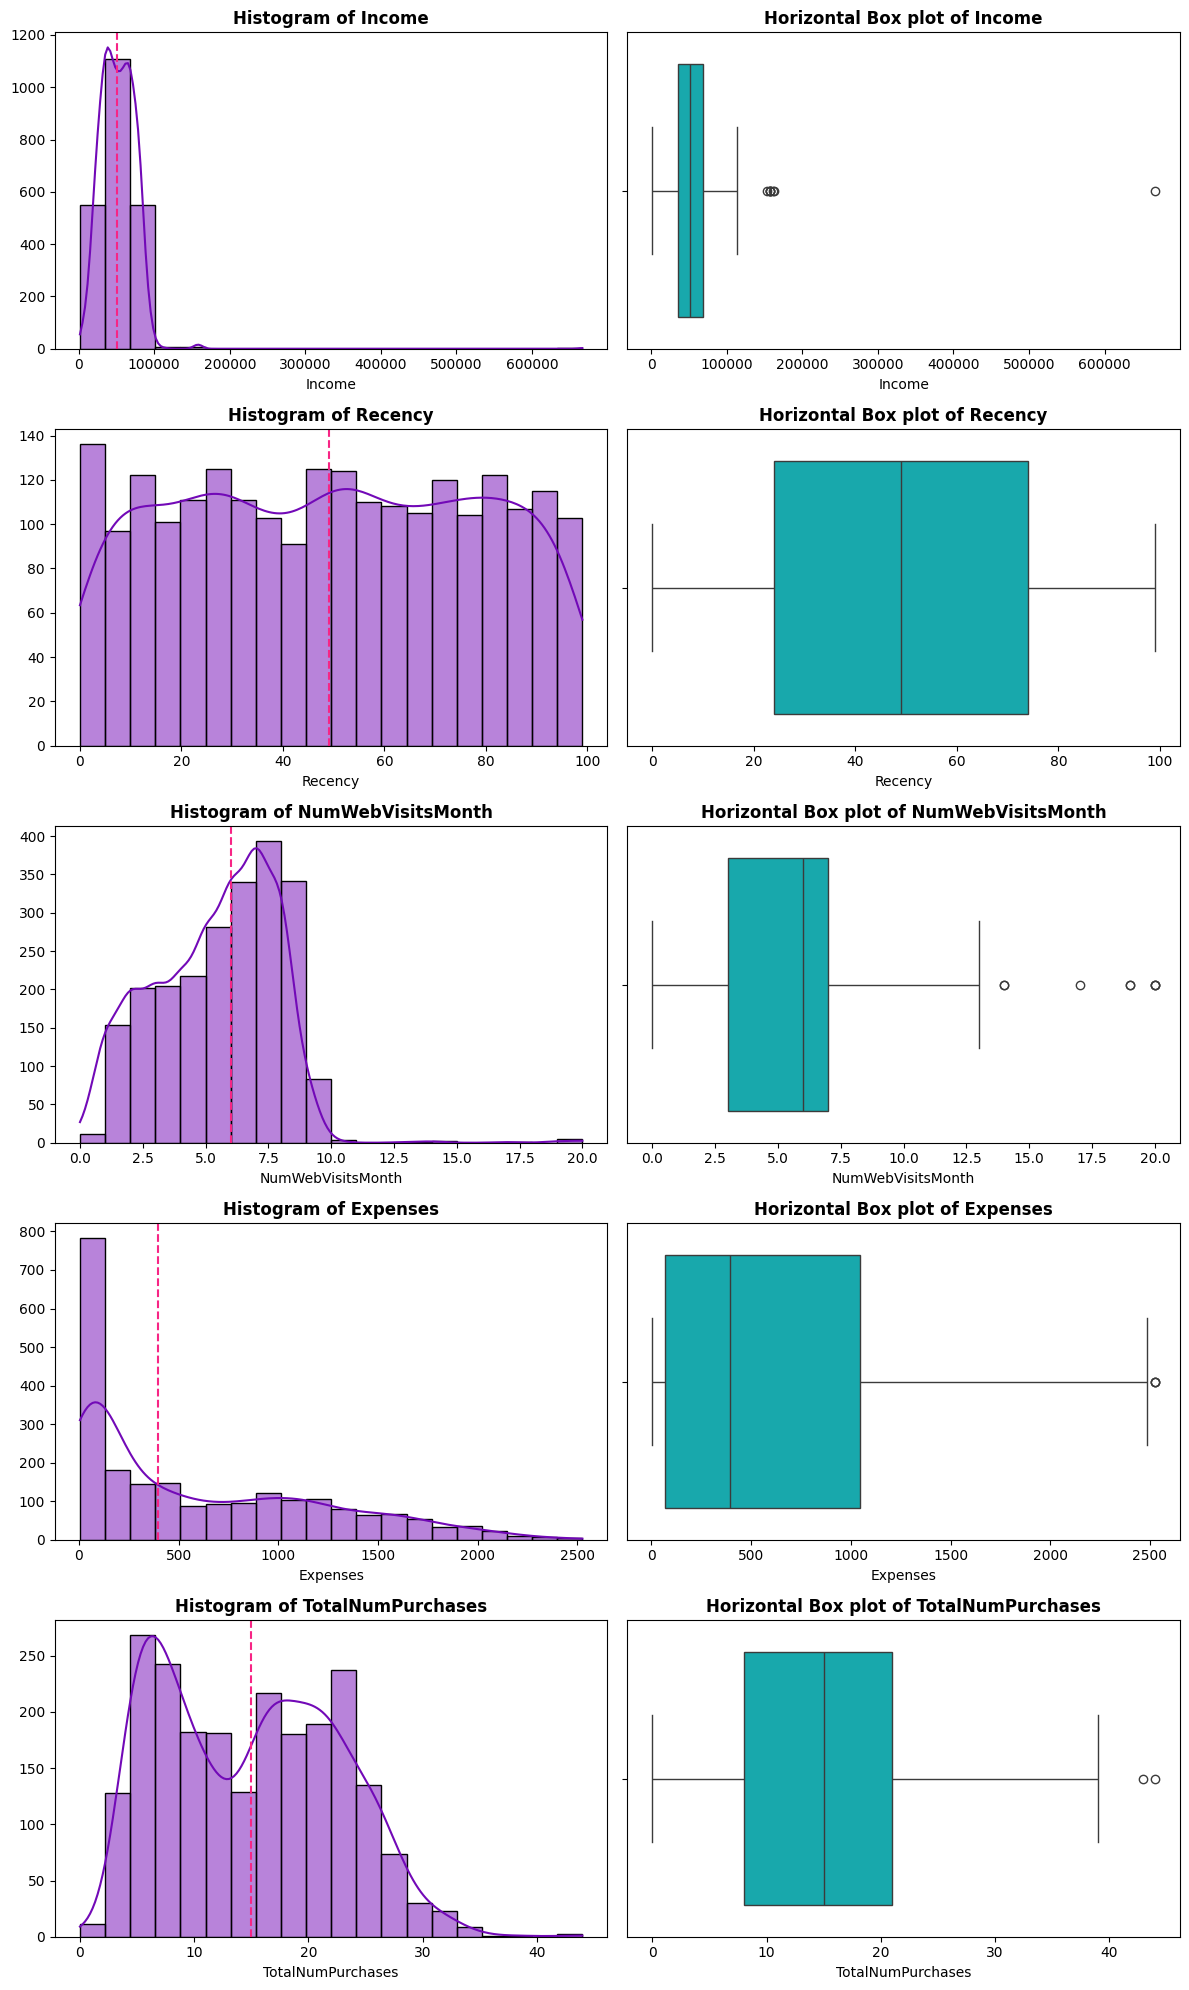

In [221]:
def plot_numerical_features(df=df, numerical_features = num_features):
    fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    axes = np.atleast_2d(axes)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#7209b7", bins = 20, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"Histogram of {feature}", weight="bold")
        axes[i, 0].set_ylabel("")
        axes[i, 0].axvline(df[feature].median(), color="#f72585", linestyle="--", label="Median Train")
        # axes[i, 0].grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

        sns.boxplot(data=df[feature], color="#00BFC4", orient="h", ax=axes[i, 1])
        axes[i, 1].set_title(f"Horizontal Box plot of {feature}", weight="bold")
        axes[i, 1].set_xlabel(feature)
        # axes[i, 1].grid(axis="x", color="gray", linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [222]:
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+10f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Income                         |  +6.763487 | Highly skewed
Expenses                       |  +0.860841 | Moderately skewed
TotalNumPurchases              |  +0.252111 | Approximately symmetric
NumWebVisitsMonth              |  +0.207926 | Approximately symmetric
Recency                        |  -0.001987 | Approximately symmetric
----------------------------------------------------------------------


**Insights on Numerical Feature Distributions**

* **Income:** Highly right-skewed (+6.76) → most customers have **average income**, with a few **very high-income outliers**.
* **Expenses:** Moderately right-skewed (+0.86) → spending is mostly **low to medium**, with some **high spenders**.
* **TotalNumPurchases:** Nearly symmetric (+0.25) → purchase frequency is **evenly distributed** across customers.
* **NumWebVisitsMonth:** Approximately symmetric (+0.21) → **consistent web visit behavior**, few extremely active users.
* **Recency:** Almost symmetric (-0.00) → **balanced distribution** between new and old customers.

**Summary:**
Overall, the dataset shows **balanced and stable distributions**, with only **Income** being significantly skewed due to **a few high-value outliers**.
→ Suggest applying **log transformation or capping** on `Income` to reduce its impact on modeling.

## Categorical Feature Distributions

In [223]:
def color(n_colors=2):
    return sns.color_palette("RdYlGn", n_colors=n_colors)

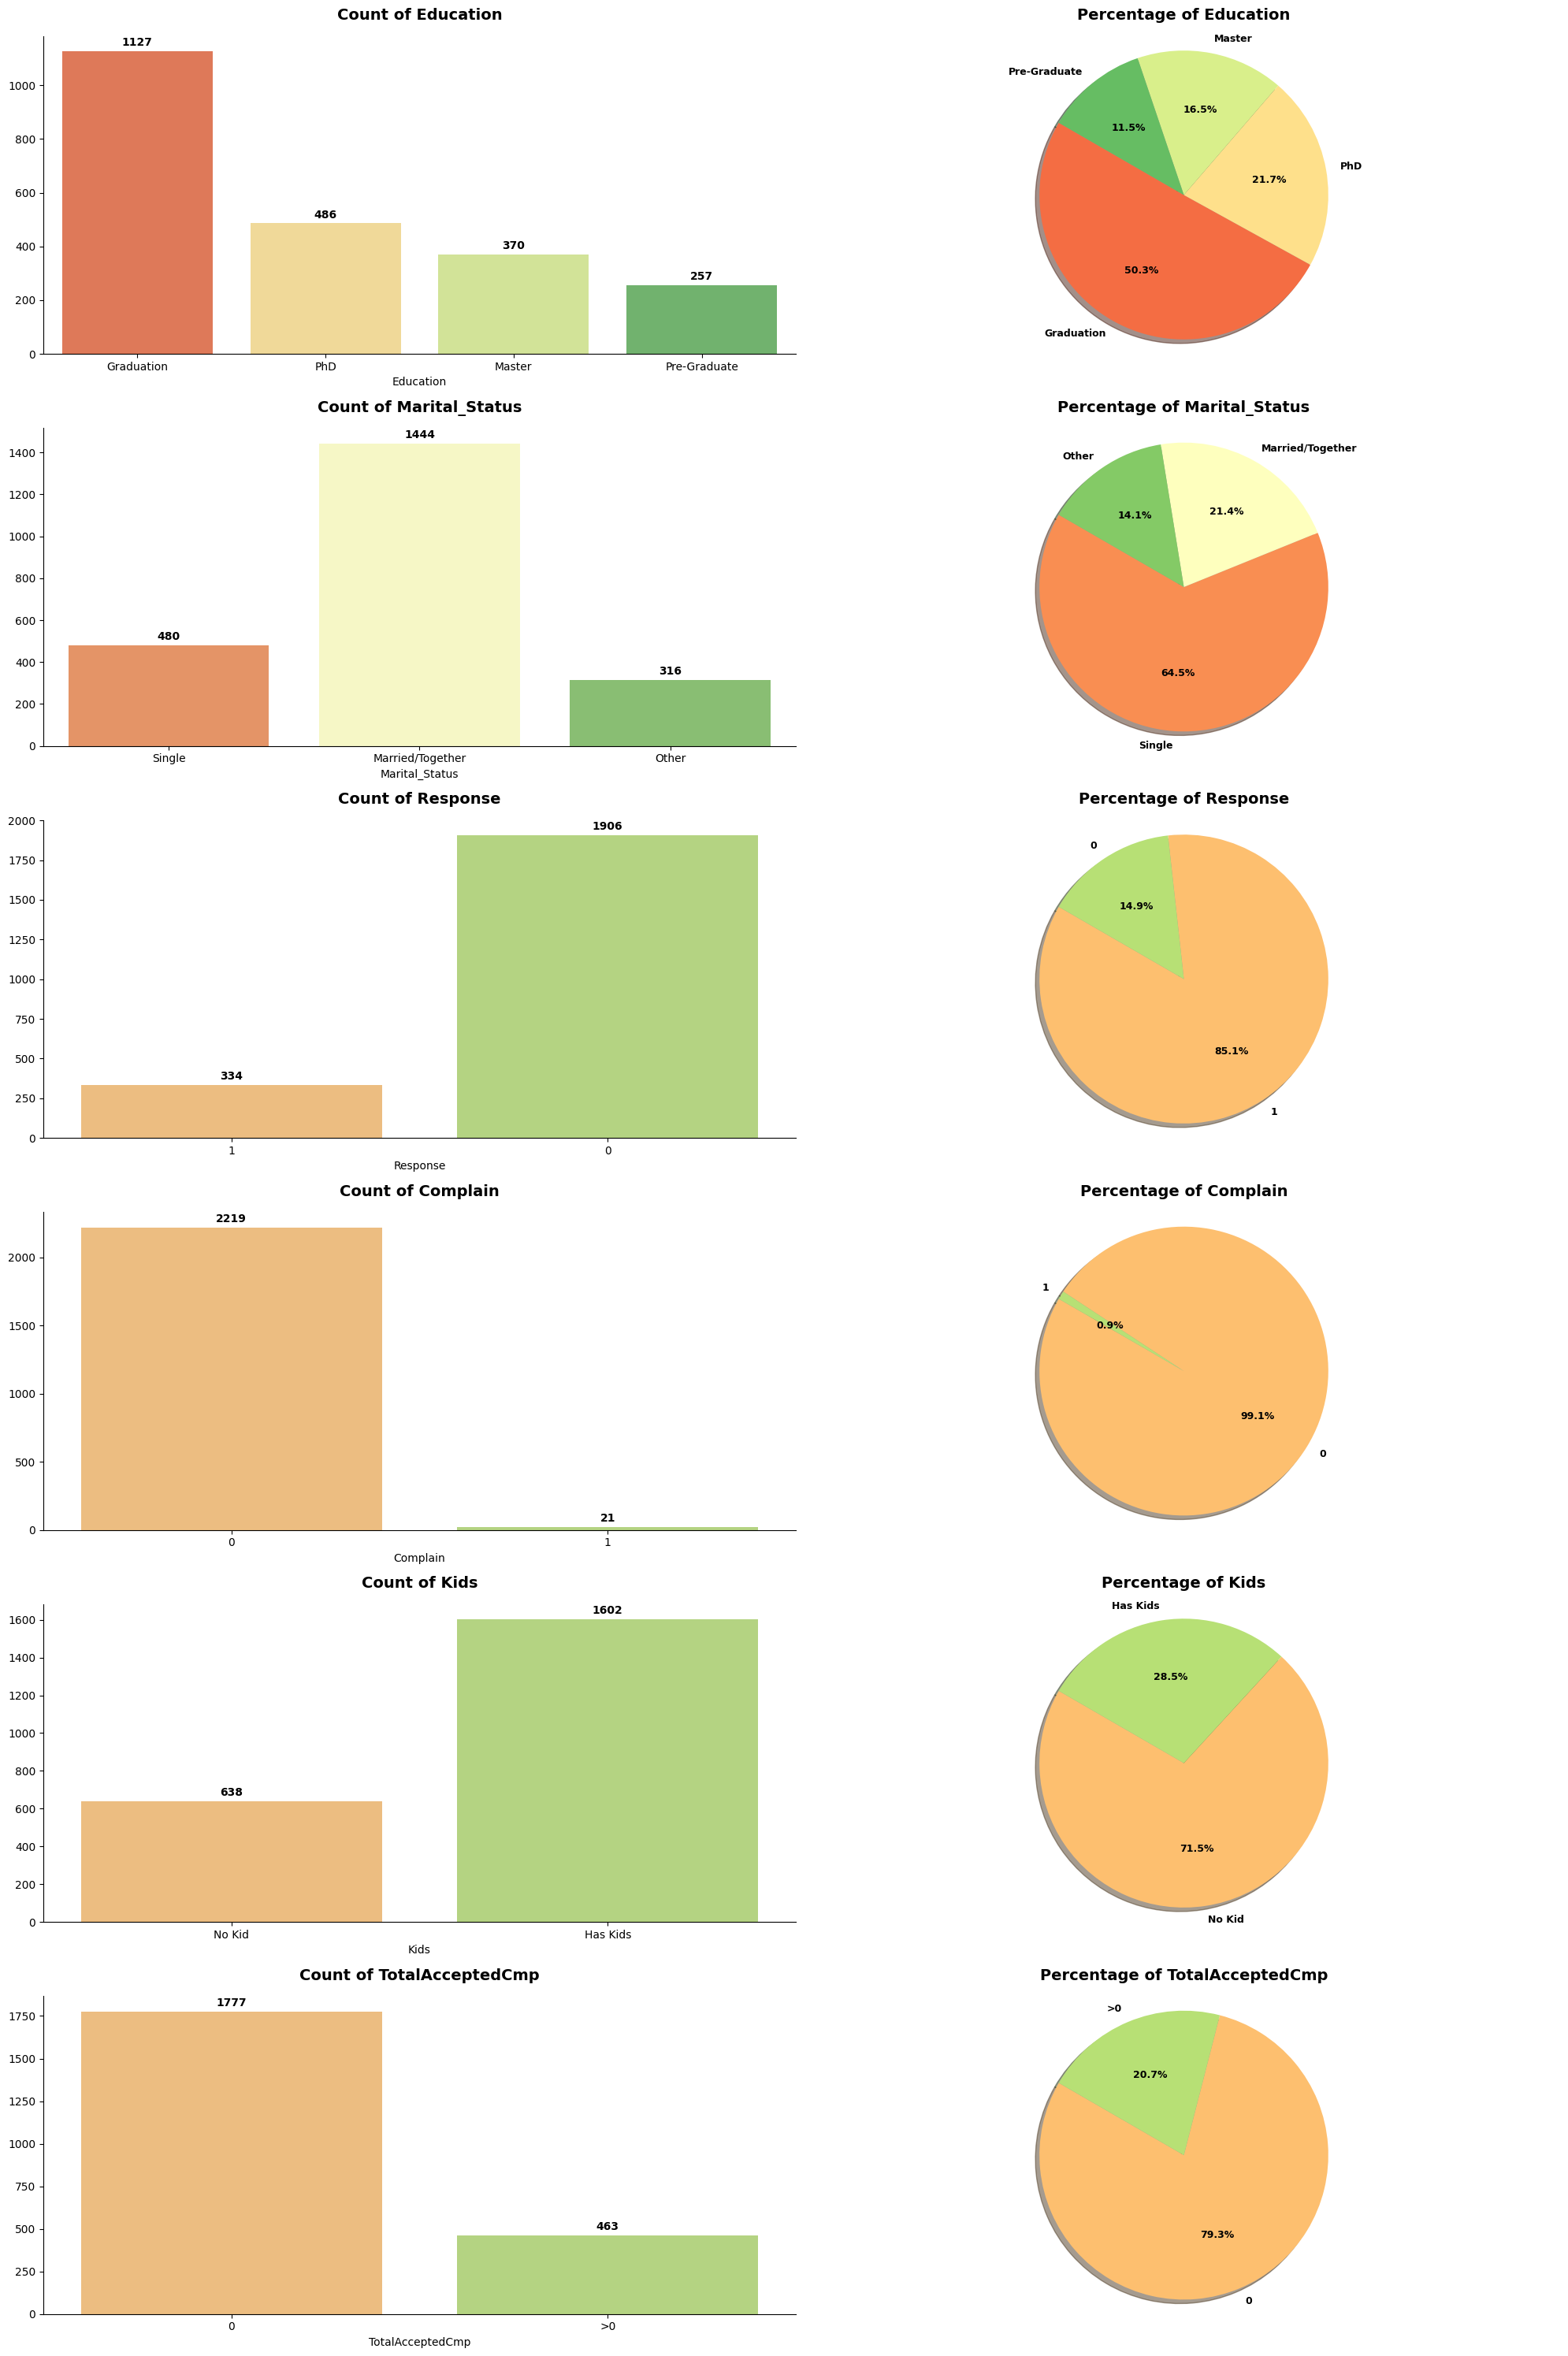

In [224]:
def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(20, len(cat_features) * 5))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        order_feature = df[feature].unique().tolist()
        # ----------------------------
        # LEFT: Countplot
        # ----------------------------
        sns.countplot(data=df, x=feature, ax=ax[i, 0], palette="RdYlGn", order=order_feature)
        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        ax[i, 0].set_ylabel("")
        if len(df[feature].unique()) > 4:
            ax[i, 0].set_xticklabels(ax[i, 0].get_xticklabels(), rotation=30)
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # ----------------------------
        # RIGHT: Pie Chart
        # ----------------------------
        feature_counts = df[feature].value_counts(normalize=True)
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=order_feature, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 9, "weight": "bold"}
        )
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    plt.tight_layout()
    plt.show()
plot_categorical_distribution(df=df, cat_features=cat_features)

**Categorical Feature Insights**

* **Education:** Over **50% graduated**, indicating a **well-educated customer base**.
* **Marital Status:** **Married/Together (64%)** dominate → suggests **family-oriented customers**.
* **Response:** Only **15% responded** to campaigns → **low marketing engagement**.
* **Complain:** **<1%** submitted complaints → overall **customer satisfaction is high**.
* **Kids:** **71% have children**, showing **family presence in most households**.
* **TotalAcceptedCmp:** **~80% never accepted** any campaign → strong **potential for re-engagement**.

**🧠 Summary:**
Customers are mainly **educated, married, and satisfied**, but **marketing response is weak** → business should **improve personalization and retention campaigns**.

## RFM Analysis

**Customer segmentation based on RFM Score**

| Segment                        | Description                                                                  | RFM Condition    |
| ------------------------------ | ---------------------------------------------------------------------------- | -------------------------- |
| **Champions / Best Customers** | Most valuable customers: recent activity, frequent transactions, high spend. | `R ≥ 4, F ≥ 4, M ≥ 4`      |
| **Loyal Customers**            | Loyal customers: purchase frequently and spend consistently well.            | `F ≥ 4, M ≥ 3`             |
| **Potential Loyalists**        | New customers with decent frequency/spending, potential to become loyal.     | `R ≥ 4, F ≥ 2`             |
| **At Risk**                    | Previously frequent/high spenders but inactive for a long time.              | `R ≤ 2, F ≥ 3`             |
| **New Customers**              | Recently joined, made transactions recently but with low frequency.          | `R ≥ 4, F = 1`             |
| **Hibernating / Churn**        | Customers inactive for a long time with low spending.                        | `R = 1, F = 1, M = 1`      |
| **Others**                     | Customers not falling into the above categories.                             | Different from above rules |


In [227]:
rfm_df = df[["ID", "Recency"]].copy()
rfm_df["Frequency"] = df["TotalNumPurchases"].copy()
rfm_df["Monetary"] = df["Expenses"].copy()
display(rfm_df.head(10))

,ID,Recency,Frequency,Monetary
0,5524,58,25,1617
1,2174,38,6,27
2,4141,26,21,776
3,6182,26,8,53
4,5324,94,19,422
5,7446,16,22,716
6,965,34,21,590
7,6177,32,10,169
8,4855,19,6,46
9,5899,68,2,49


In [228]:
rfm_df["R"] = pd.qcut(rfm_df["Recency"], 5, labels=[5,4,3,2,1])
rfm_df["F"] = pd.qcut(rfm_df["Frequency"], 5, labels=[1,2,3,4,5])
rfm_df["M"] = pd.qcut(rfm_df["Monetary"], 5, labels=[1,2,3,4,5])

rfm_df["RFM_Score"] = rfm_df["R"].astype(str) + rfm_df["F"].astype(str) + rfm_df["M"].astype(str)
display(rfm_df.head(10))

,ID,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,5524,58,25,1617,3,5,5,355
1,2174,38,6,27,4,1,1,411
2,4141,26,21,776,4,4,4,444
3,6182,26,8,53,4,2,1,421
4,5324,94,19,422,1,4,3,143
5,7446,16,22,716,5,4,4,544
6,965,34,21,590,4,4,3,443
7,6177,32,10,169,4,2,2,422
8,4855,19,6,46,5,1,1,511
9,5899,68,2,49,2,1,1,211


In [229]:
def classify_rfm(row):
    r, f, m = row["R"], row["F"], row["M"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    elif f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r >= 4  and f == 1:
        return "New Customers"
    elif r == 1  and f == 1 and m == 1:
        return "Churn Customers"
    else:
        return "Other"

rfm_df["RFM_Segment"] = rfm_df.apply(classify_rfm, axis=1)
display(rfm_df.head(10))

,ID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Segment
0,5524,58,25,1617,3,5,5,355,Loyal Customers
1,2174,38,6,27,4,1,1,411,New Customers
2,4141,26,21,776,4,4,4,444,Best Customers
3,6182,26,8,53,4,2,1,421,Potential Loyalists
4,5324,94,19,422,1,4,3,143,Loyal Customers
5,7446,16,22,716,5,4,4,544,Best Customers
6,965,34,21,590,4,4,3,443,Loyal Customers
7,6177,32,10,169,4,2,2,422,Potential Loyalists
8,4855,19,6,46,5,1,1,511,New Customers
9,5899,68,2,49,2,1,1,211,Other


In [230]:
# Create a layout with clear headers, centered text, and nicely formatted numbers
summary_rfm = (
    rfm_df.groupby("RFM_Segment").agg({
        "Recency": ["mean", "min", "max"],
        "Frequency": ["mean", "min", "max"],
        "Monetary": ["mean", "min", "max"],
        "ID": "count"
    })
    .sort_values(("Monetary", "mean"), ascending=False)
    .style
    .set_caption("RFM Summary by Segment")
    .format(precision=0)  # Round numbers
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]}
    ])
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    .background_gradient(subset=[("Recency", "mean"), ("Frequency", "mean"), ("Monetary", "mean"), ("ID", "count")], cmap="Greens")
)
display(summary_rfm)


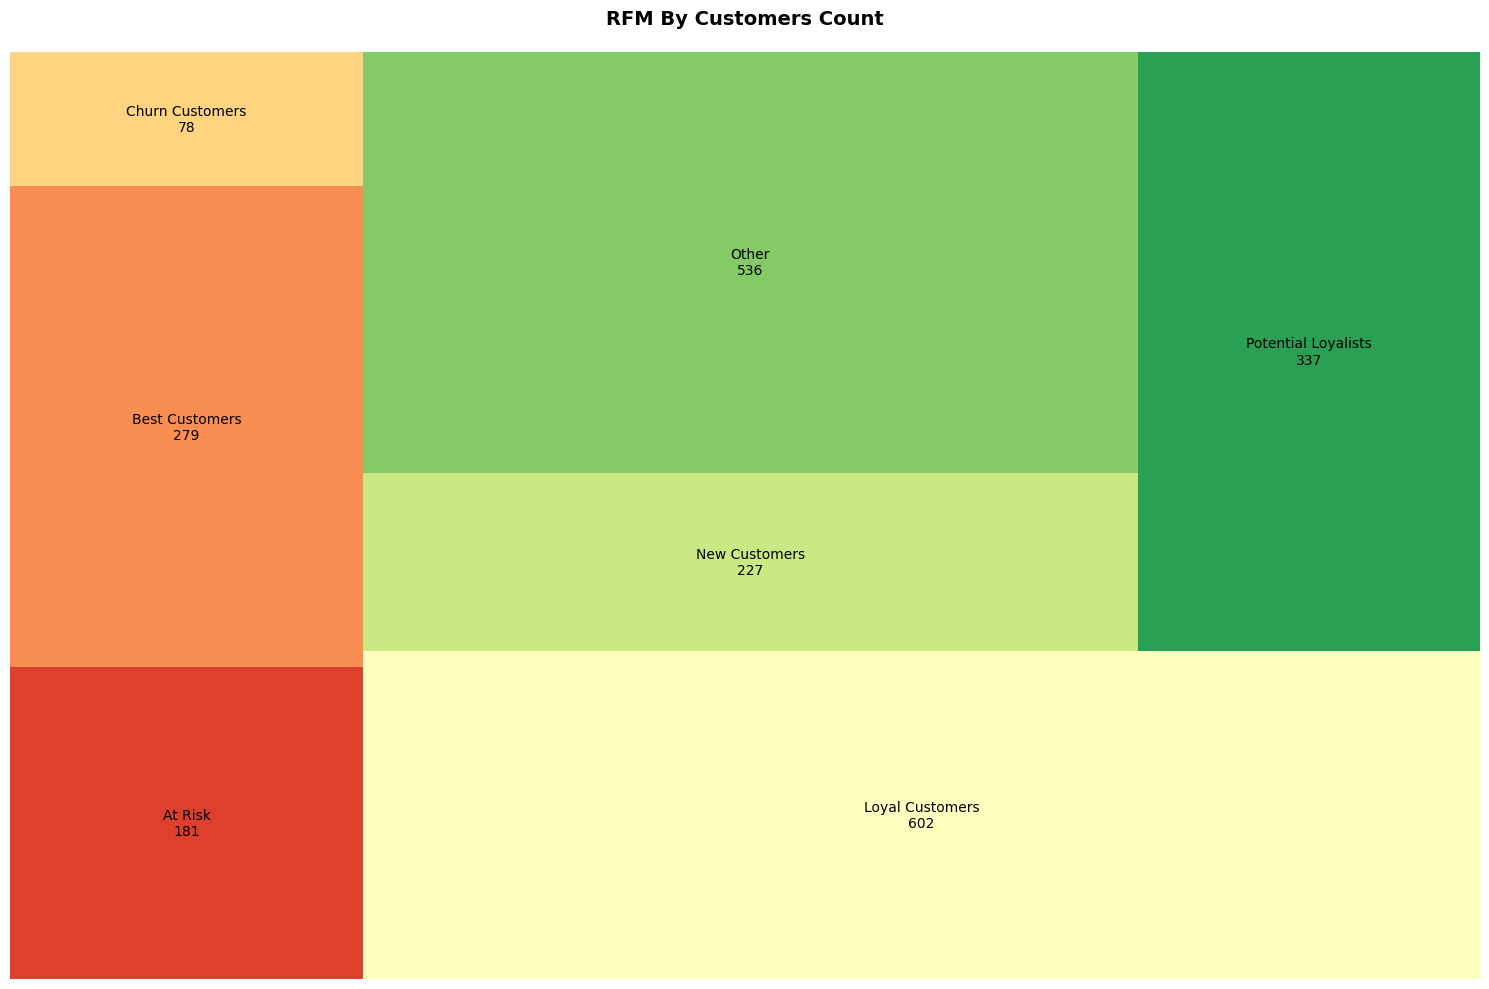

In [231]:
import squarify

rfm_df = rfm_df.astype({
    "R": "int8",
    "F": "int8",
    "M": "int8"
})

rfm_summarised = rfm_df.groupby (by = "RFM_Segment", as_index = False)\
                        .agg (
                            customersCount = ("ID", "nunique"),
                            total_R = ("R", "sum"),
                            total_F = ("F", "sum"),
                            total_M = ("M", "sum")
                        )

plt.figure(figsize=(15, 10))
squarify.plot(
    rfm_summarised["customersCount"].to_list(),
    label = rfm_summarised["RFM_Segment"] + "\n" + rfm_summarised["customersCount"].astype(str),
    color = color(n_colors=rfm_df["RFM_Segment"].nunique())
)
plt.title ("RFM By Customers Count", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

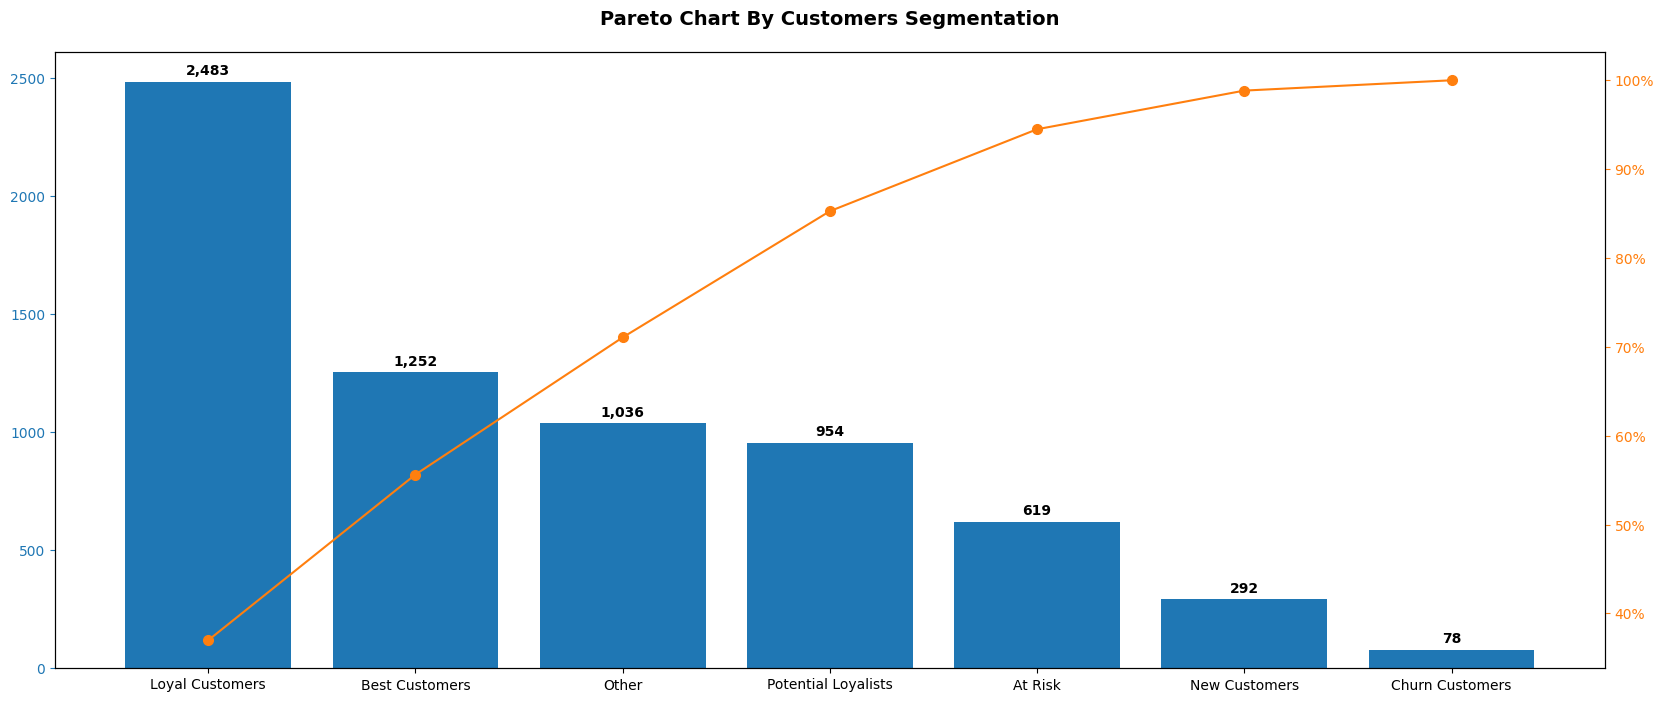

In [232]:
from matplotlib.ticker import PercentFormatter

rfm_summarised = rfm_summarised.sort_values(by="total_M", ascending=False)
rfm_summarised["cumpercentage"] = rfm_summarised["total_M"].cumsum() / rfm_summarised["total_M"].sum() * 100

fig, ax = plt.subplots(figsize=(20, 8))

bars = ax.bar(rfm_summarised["RFM_Segment"], rfm_summarised["total_M"], color="C0")

ax1 = ax.twinx()
ax1.plot(rfm_summarised["RFM_Segment"], rfm_summarised["cumpercentage"], color="C1", marker="o", ms=7)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Add value labels on top of each bar
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in rfm_summarised["total_M"]], padding=3, fontsize=10, color="black", weight="bold")

ax.tick_params(axis="y", colors="C0")
ax1.tick_params(axis="y", colors="C1")

plt.title("Pareto Chart By Customers Segmentation", fontsize=14, pad=20, weight="bold")
plt.show()

**RFM Segmentation Insights**

* **Best & Loyal Customers** make up the largest share (**~40% of total customers**) with **low Recency** and **high Frequency & Monetary**, indicating **highly valuable and engaged users**.
* **Potential Loyalists** (~15%) show **moderate purchase frequency and spending** → can be converted into loyal customers through consistent engagement.
* **At Risk** (~8%) have **high Recency** and **declining spending** → need **re-engagement strategies** to prevent churn.
* **New Customers** and **Other** are smaller groups, representing **new or unstable relationships**.
* **Churn Customers** (~3%) show **no recent activity**, indicating **lost customers**.

**Key Takeaway:**
Most revenue comes from **Loyal** and **Best Customers**.
Focus on **retaining and maximizing CLV** of these two groups, while **reactivating the “At Risk” segment** to boost long-term profitability.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Re-check and Handling Skew

In [233]:
skew_feature, skew_df = check_skewness(data=df, numerical_features=num_features)


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Income                         |  +6.763487 | Highly skewed
Expenses                       |  +0.860841 | Moderately skewed
TotalNumPurchases              |  +0.252111 | Approximately symmetric
NumWebVisitsMonth              |  +0.207926 | Approximately symmetric
Recency                        |  -0.001987 | Approximately symmetric
----------------------------------------------------------------------


In [234]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
    
):
    """
    Handle skewed numerical features by applying appropriate transformations,
    *forcing* certain columns to be transformed even if they don't exceed skew_threshold.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely
    - dataset: Name of dataset

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    - pt_dict: dict mapping each YJ‑transformed col → its PowerTransformer
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))
    print(to_transform)

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

In [235]:
processed_df, transformed_columns, sparse_columns, skewed_columns, pt_dict = handle_skewed_features(df=df, num_features=skew_feature)
num_features = ["PT_Income", "Recency", "NumWebVisitsMonth", "PT_Expenses", "TotalNumPurchases"]
skew_feature, skew_df = check_skewness(data=processed_df, numerical_features=num_features)

['Expenses', 'Income']

🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
TotalNumPurchases              |  +0.252111 | Approximately symmetric
PT_Income                      |  +0.226998 | Approximately symmetric
NumWebVisitsMonth              |  +0.207926 | Approximately symmetric
PT_Expenses                    |  -0.120068 | Approximately symmetric
Recency                        |  -0.001987 | Approximately symmetric
----------------------------------------------------------------------


## Re-check Outliers

In [236]:
checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,PT_Income,17
1,NumWebVisitsMonth,8
2,TotalNumPurchases,2


## Scale and Encoding

In [237]:
X = processed_df[num_features + cat_features].copy()

# There are no **missing values** in dataset. But we will still handle missing values ​​to check the data in the future.
num_standard_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(transformers=[
    ("num_standard", num_standard_scaler_transformer, num_features),
    ("cat_onehot", cat_onehot_transformer, cat_features)
])

preprocessor.fit(X)
X_prepared = preprocessor.transform(X)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("cat_onehot__", "").replace("PT_", "") for col in list_feature_prepared]
clean_features

['Income',
 'Recency',
 'NumWebVisitsMonth',
 'Expenses',
 'TotalNumPurchases',
 'Education_Graduation',
 'Education_Master',
 'Education_PhD',
 'Education_Pre-Graduate',
 'Marital_Status_Married/Together',
 'Marital_Status_Other',
 'Marital_Status_Single',
 'Response_0',
 'Response_1',
 'Complain_0',
 'Complain_1',
 'Kids_Has Kids',
 'Kids_No Kid',
 'TotalAcceptedCmp_0',
 'TotalAcceptedCmp_>0']

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>


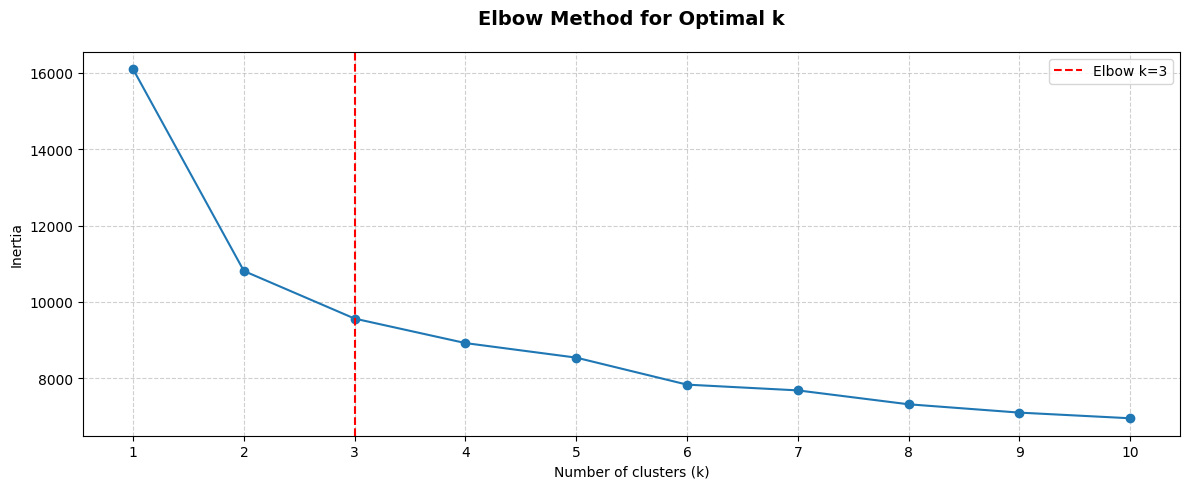

Optimal k suggested by Elbow: 3


In [238]:
# If X_prepared is sparse, convert to dense
X_use = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared

# --- Elbow Method ---
inertia = []
K_elbow = range(1, 11)  # k = 1..10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_use)
    inertia.append(kmeans.inertia_)

# Find the elbow point
kneedle = KneeLocator(list(K_elbow), inertia, curve="convex", direction="decreasing")
k_best_elbow = kneedle.knee

# Plot Elbow
plt.figure(figsize=(12, 5))
plt.plot(list(K_elbow), inertia, marker="o", linestyle="-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, 11))

# Mark elbow if found
if k_best_elbow is not None:
    plt.axvline(k_best_elbow, linestyle="--", label=f"Elbow k={k_best_elbow}", color = "red")
    plt.legend()

plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Elbow: {k_best_elbow}")

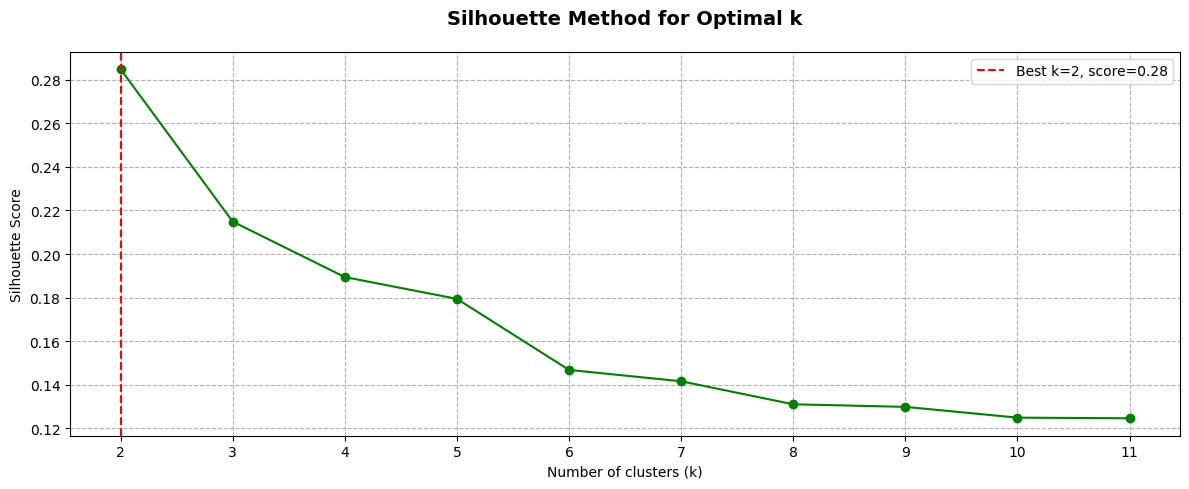

Optimal k suggested by Silhouette: 2


In [239]:
from sklearn.metrics import silhouette_score

# --- Silhouette Method ---
silhouette_scores = []
K_silhouette = range(2, 12)  # Silhouette score cannot be computed for k=1

# Loop through different k values
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_use)
    score = silhouette_score(X_use, labels)
    silhouette_scores.append(score)

# Find k with the highest silhouette score
best_k_silhouette = K_silhouette[silhouette_scores.index(max(silhouette_scores))]

# Plot Silhouette results
plt.figure(figsize=(12, 5))
plt.plot(list(K_silhouette), silhouette_scores, marker="o", linestyle="-", color="green")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--")
plt.xticks(range(2, 12))

# Highlight the best silhouette score
plt.axvline(best_k_silhouette, linestyle="--", color="red",
            label=f"Best k={best_k_silhouette}, score={max(silhouette_scores):.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Silhouette: {best_k_silhouette}")

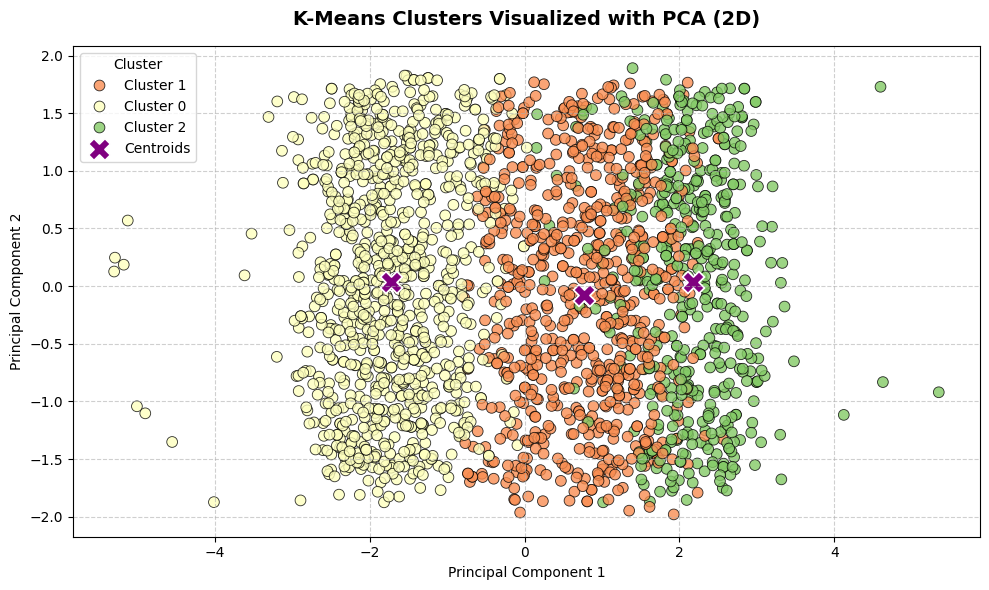

In [240]:
# Fit K-means with the chosen number of clusters (k=3 following Elbow Method)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans.fit(X_use)

# Assign clusters and calculate distance to cluster centroid
df["Cluster"] = kmeans.labels_
df["DistanceToCentroid"] = np.linalg.norm(X_use - kmeans.cluster_centers_[kmeans.labels_], axis=1)
df["Cluster"] = df["Cluster"].replace({1: "Cluster 1", 2: "Cluster 2", 0: "Cluster 0"})

# --- PCA Visualization using Seaborn ---
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_use)

# Add PCA components to dataframe
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Create figure
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="RdYlGn", s=60,
                alpha=0.8, edgecolor="black")

# Plot centroids (transformed into PCA space)
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(x=centroids_pca[:, 0], y=centroids_pca[:, 1], s=250, color="purple", marker="X", label="Centroids")

# Formatting
plt.title("K-Means Clusters Visualized with PCA (2D)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**PCA Cluster Visualization Insights**

The PCA plot confirms that **K-Means segmentation (k=3)** effectively distinguishes distinct customer groups with minimal overlap — a strong sign of **valid cluster structure**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Profiling Customers</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Profiling Customers
    </h1>
</div>


In [241]:
merged_df = pd.merge(df, rfm_df[["ID", "RFM_Segment"]], on="ID", how="inner")
merged_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,NumWebVisitsMonth,Complain,Response,Kids,Expenses,TotalAcceptedCmp,TotalNumPurchases,Cluster,DistanceToCentroid,PCA1,PCA2,RFM_Segment
0,5524,1957,Graduation,Single,58138.0,04-09-2012,58,7,0,1,No Kid,1617,0,25,Cluster 1,2.459874,1.488204,0.051252,Loyal Customers
1,2174,1954,Graduation,Single,46344.0,08-03-2014,38,5,0,0,Has Kids,27,0,6,Cluster 0,1.654656,-1.485333,-0.255688,New Customers
2,4141,1965,Graduation,Married/Together,71613.0,21-08-2013,26,4,0,0,No Kid,776,0,21,Cluster 2,1.591160,1.543248,-0.721990,Best Customers
3,6182,1984,Graduation,Married/Together,26646.0,10-02-2014,26,6,0,0,Has Kids,53,0,8,Cluster 0,1.201121,-1.879731,-0.702165,Potential Loyalists
4,5324,1981,PhD,Married/Together,58293.0,19-01-2014,94,5,0,0,Has Kids,422,0,19,Cluster 1,1.986625,0.508080,1.538408,Loyal Customers


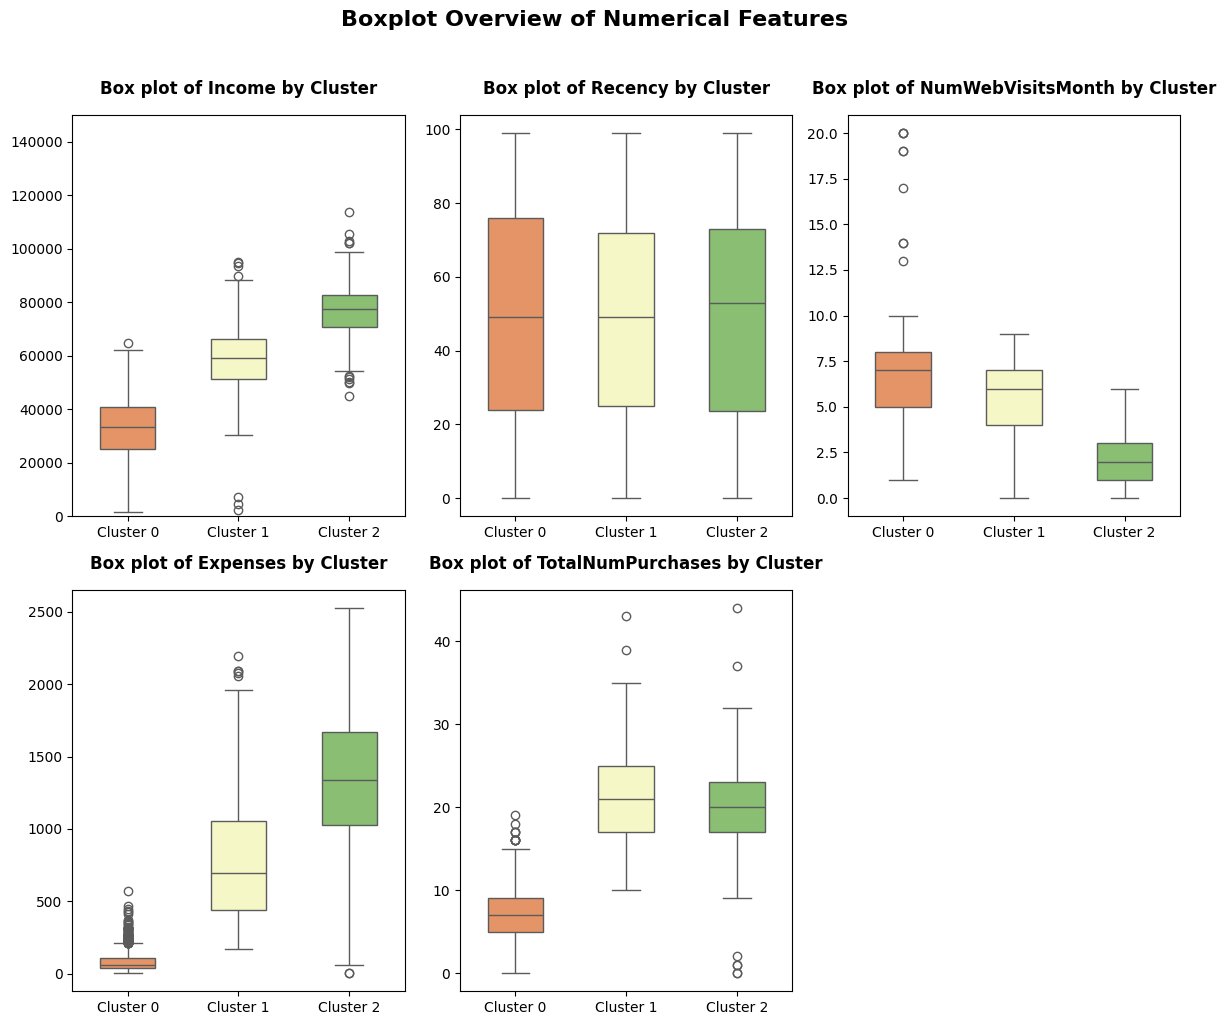

In [252]:
num_features = ["Income", "Recency", "NumWebVisitsMonth", "Expenses", "TotalNumPurchases"]
cat_features = ["Education", "Marital_Status", "Response", "Complain", "Kids", "TotalAcceptedCmp", "RFM_Segment"]

def plot_boxplots(df, num_features, n_cols=3):

    # Handle empty list
    if not num_features:
        print("⚠️ No numerical features provided!")
        return

    # Determine layout
    n_rows = int(np.ceil(len(num_features) / n_cols))
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(12, len(num_features) * 2))

    # Flatten ax for consistent iteration
    ax = np.array(ax).flatten()

    # Plot boxplots
    for i, feature in enumerate(num_features):
        sns.boxplot(data=df, x="Cluster", y=feature, ax=ax[i], palette= "RdYlGn", width=0.5,
                    order=["Cluster 0", "Cluster 1", "Cluster 2"])
        ax[i].set_title(f"Box plot of {feature} by Cluster", fontsize=12, weight="bold", pad=15)
        ax[i].set_xlabel("")
        ax[i].set_ylabel("")
        if feature == "Income":
            ax[i].set_ylim(0, 150000)

    # Remove any unused subplot cells
    for j in range(len(num_features), len(ax)):
        fig.delaxes(ax[j])

    # Main title
    fig.suptitle("Boxplot Overview of Numerical Features", fontsize=16, weight="bold", y=1.02)

    plt.tight_layout()
    plt.show()
plot_boxplots(df=merged_df, num_features=num_features)

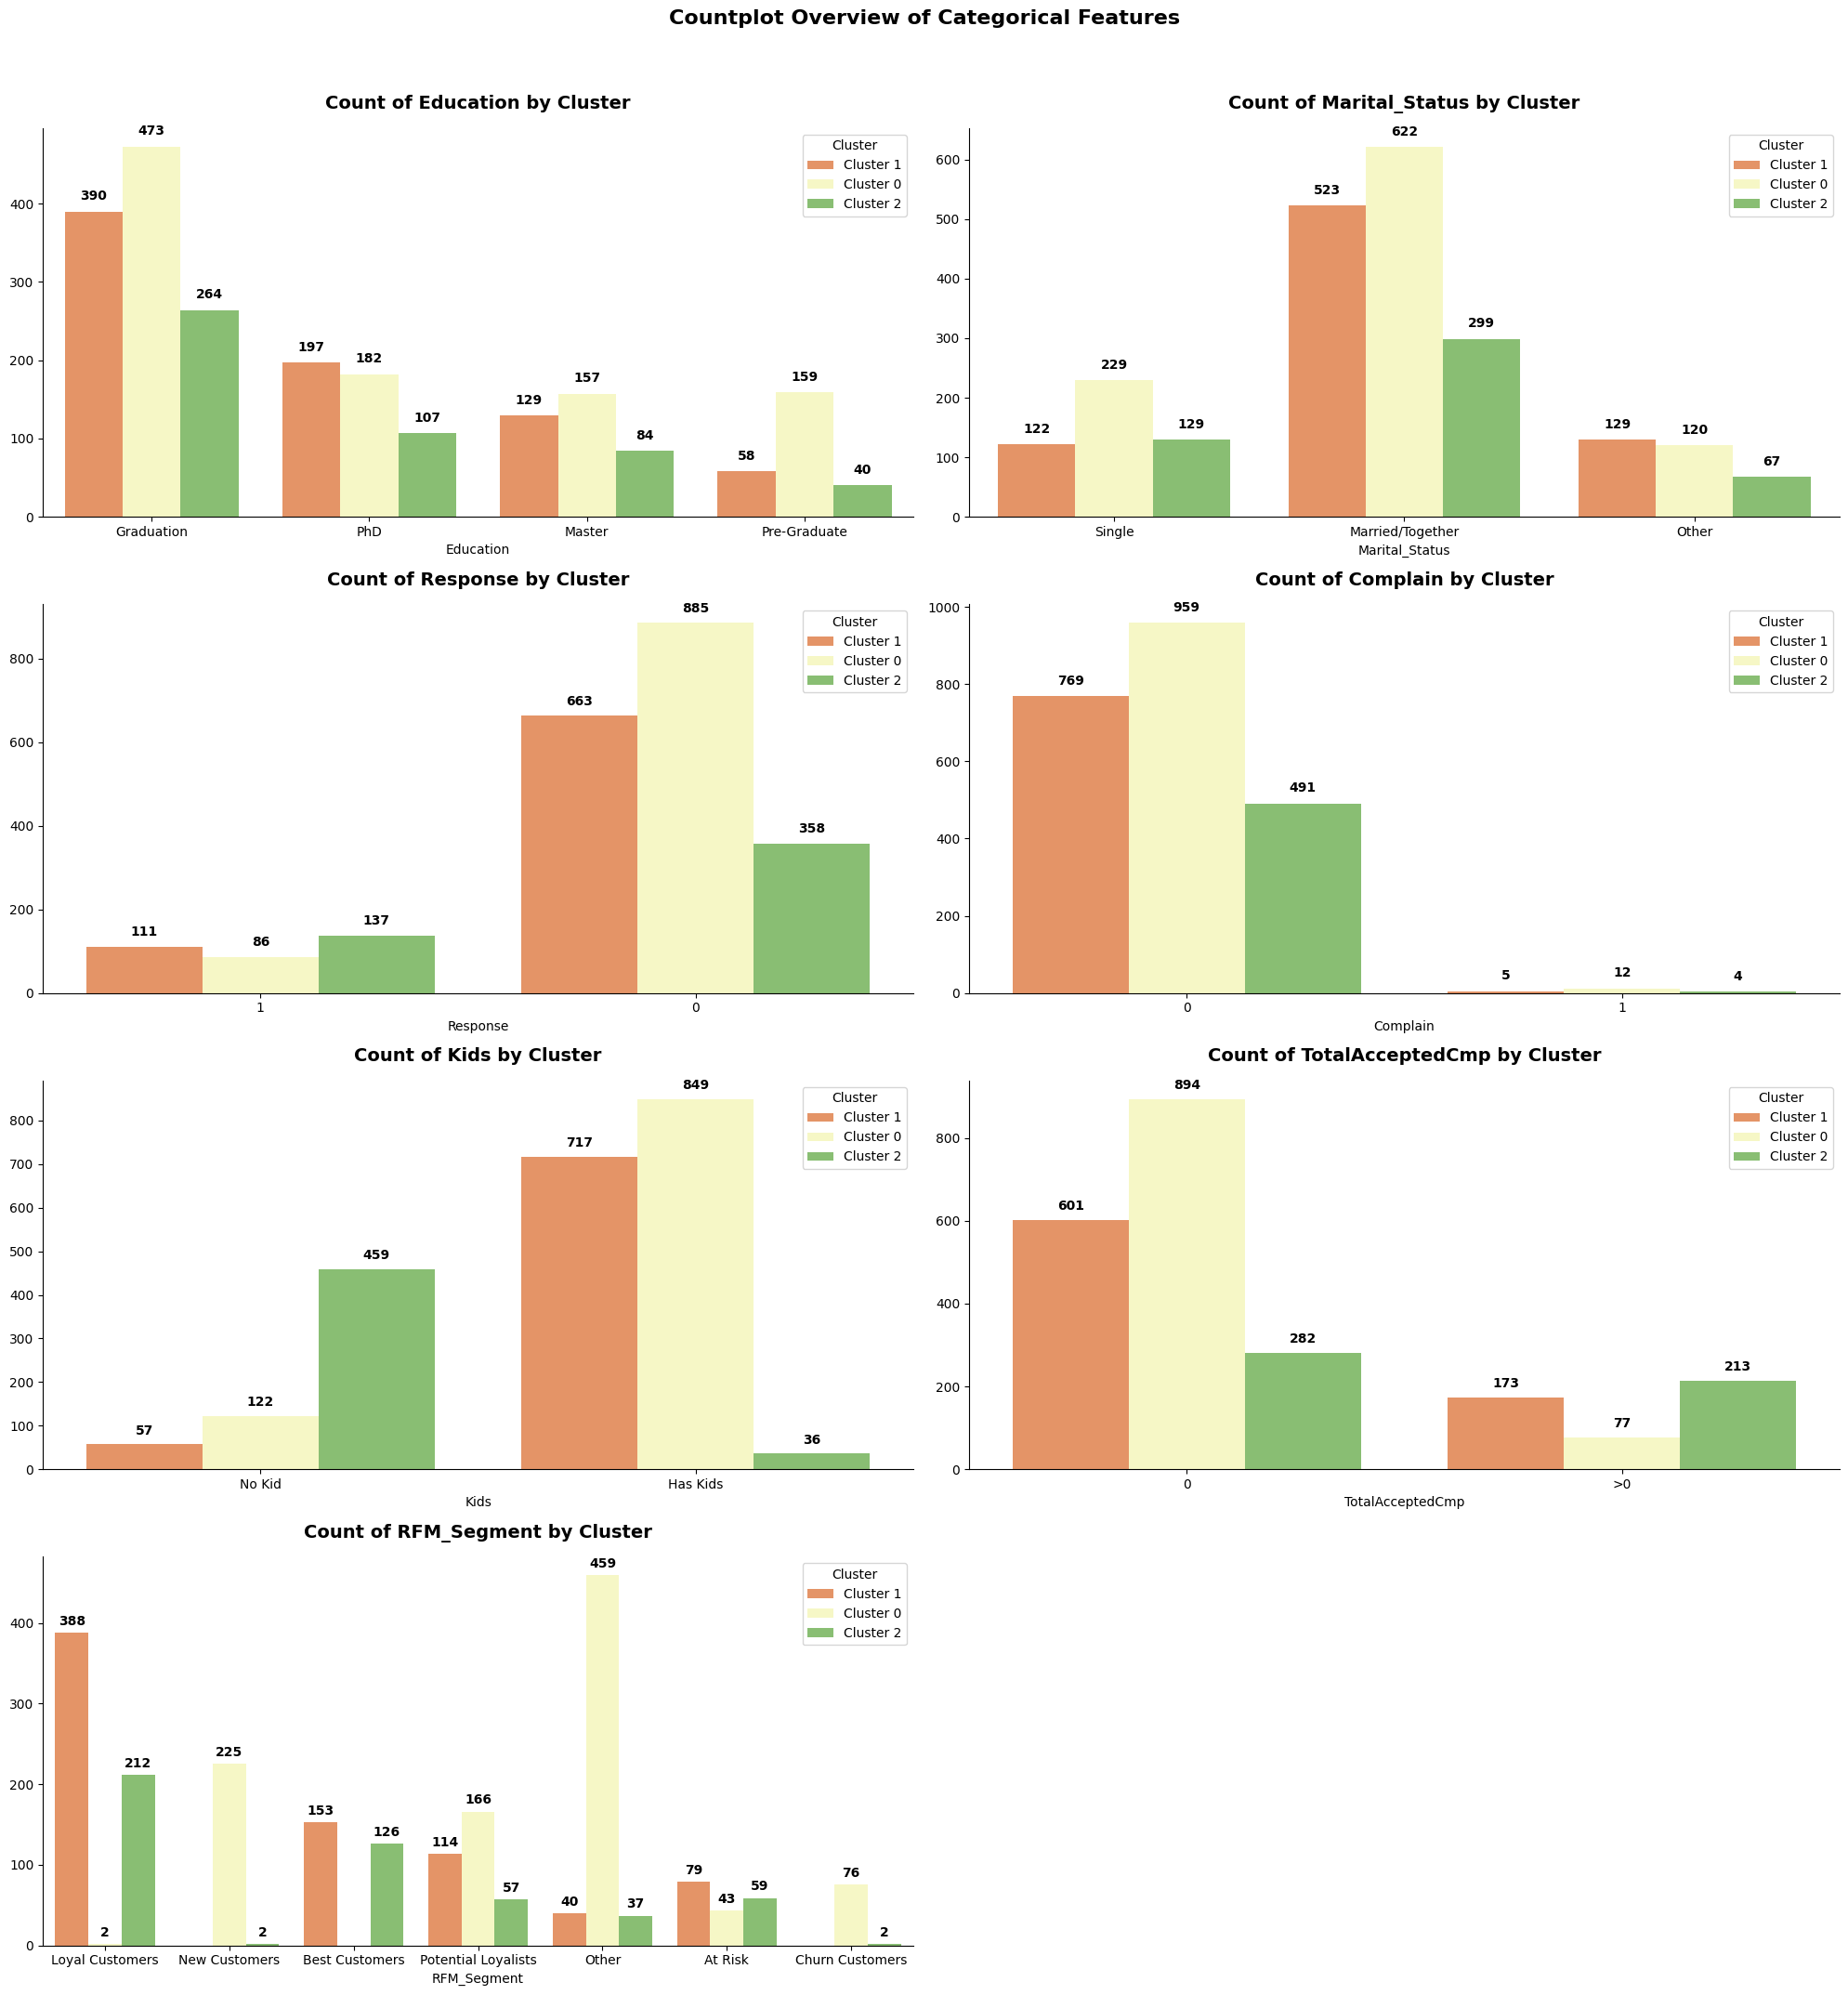

In [256]:
def plot_countplots(df, cat_features, n_cols=2):
    n_rows = int(np.ceil(len(cat_features) / n_cols))
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, len(cat_features) * 3))
    ax = np.array(ax).flatten()

    for i, feature in enumerate(cat_features):
        order_feature = df[feature].unique().tolist()
        sns.countplot(data=df, x=feature, ax=ax[i], palette="RdYlGn", order=order_feature, hue="Cluster")
        ax[i].set_title(f"Count of {feature} by Cluster", fontsize=14, pad=15, weight="bold")
        ax[i].set_xlabel(feature)
        ax[i].set_ylabel("")
        sns.despine(ax=ax[i], top=True, right=True)

        # Add count labels
        for p in ax[i].patches:
            height = p.get_height()
            if height > 0:
                x = p.get_x() + p.get_width() / 2
                ax[i].text(x, height + max(df[feature].value_counts()) * 0.01,
                            f"{int(height)}", ha="center", va="bottom",
                            fontsize=10, fontweight="bold")
            
    # Remove any unused subplot cells
    for j in range(len(cat_features), len(ax)):
        fig.delaxes(ax[j])

    # Main title
    fig.suptitle("Countplot Overview of Categorical Features", fontsize=16, weight="bold", y=1.02)

    plt.tight_layout()
    plt.show()

plot_countplots(df=merged_df, cat_features=cat_features)

**Based on the analysis:**

🟢 **Cluster 0**

* Low income group
* High *recency* → less recent activity
* Low spending and few purchases
* High number of web visits
* Mostly married / together
* Often has children
* Moderate education (Graduation level)
* Rarely accepts promotions
* Higher complaint rate

🟡 **Cluster 1**

* Medium income group
* Moderate *recency* → occasional activity
* Medium expenses and moderate purchase frequency
* Moderate web visits per month
* Married with 1–2 children
* Graduate or Postgraduate
* Sometimes accepts promotions
* Few complaints
* Average marketing response rate

🟣 **Cluster 2**

* High income group
* Low *recency* → frequent and recent purchases
* Highest expenses and highest number of purchases
* Fewer web visits per month (stable engagement)
* Fewer children or no kids
* More likely to hold a Master’s or PhD
* Actively accepts promotions and campaigns
* Very low complaint rate
* Represents **loyal and high-value customers**

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
